<a href="https://colab.research.google.com/github/jayeshkadam785/imdb-india-movies-eda/blob/main/IMDb_India_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import zipfile
import pandas as pd
import io

# Extract the zip
with zipfile.ZipFile('/content/archive.zip', 'r') as z:
    print(z.namelist())  # shows files inside
    z.extractall('/content/')

# Load CSV (check the name from namelist output)
df = pd.read_csv('/content/IMDb Movies India.csv', encoding='latin1')
print(df.shape)
df.head()

['IMDb Movies India.csv']
(15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:

import pandas as pd
import numpy as np

# Safe cleaning
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

if df['Votes'].dtype == object:
    df['Votes'] = df['Votes'].str.replace(',','')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

if df['Year'].dtype == object:
    df['Year'] = df['Year'].str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df['Rating'].fillna(df['Rating'].mean(), inplace=True)
df['Duration'].fillna(df['Duration'].mean(), inplace=True)
df['Votes'].fillna(df['Votes'].mean(), inplace=True)
df.dropna(subset=['Year'], inplace=True)

print("Cleaned shape:", df.shape)
print(df.dtypes)

Cleaned shape: (14981, 10)
Name         object
Year        float64
Duration    float64
Genre        object
Rating      float64
Votes       float64
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object


/tmp/ipykernel_4308/4021360550.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].mean(), inplace=True)
/tmp/ipykernel_4308/4021360550.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

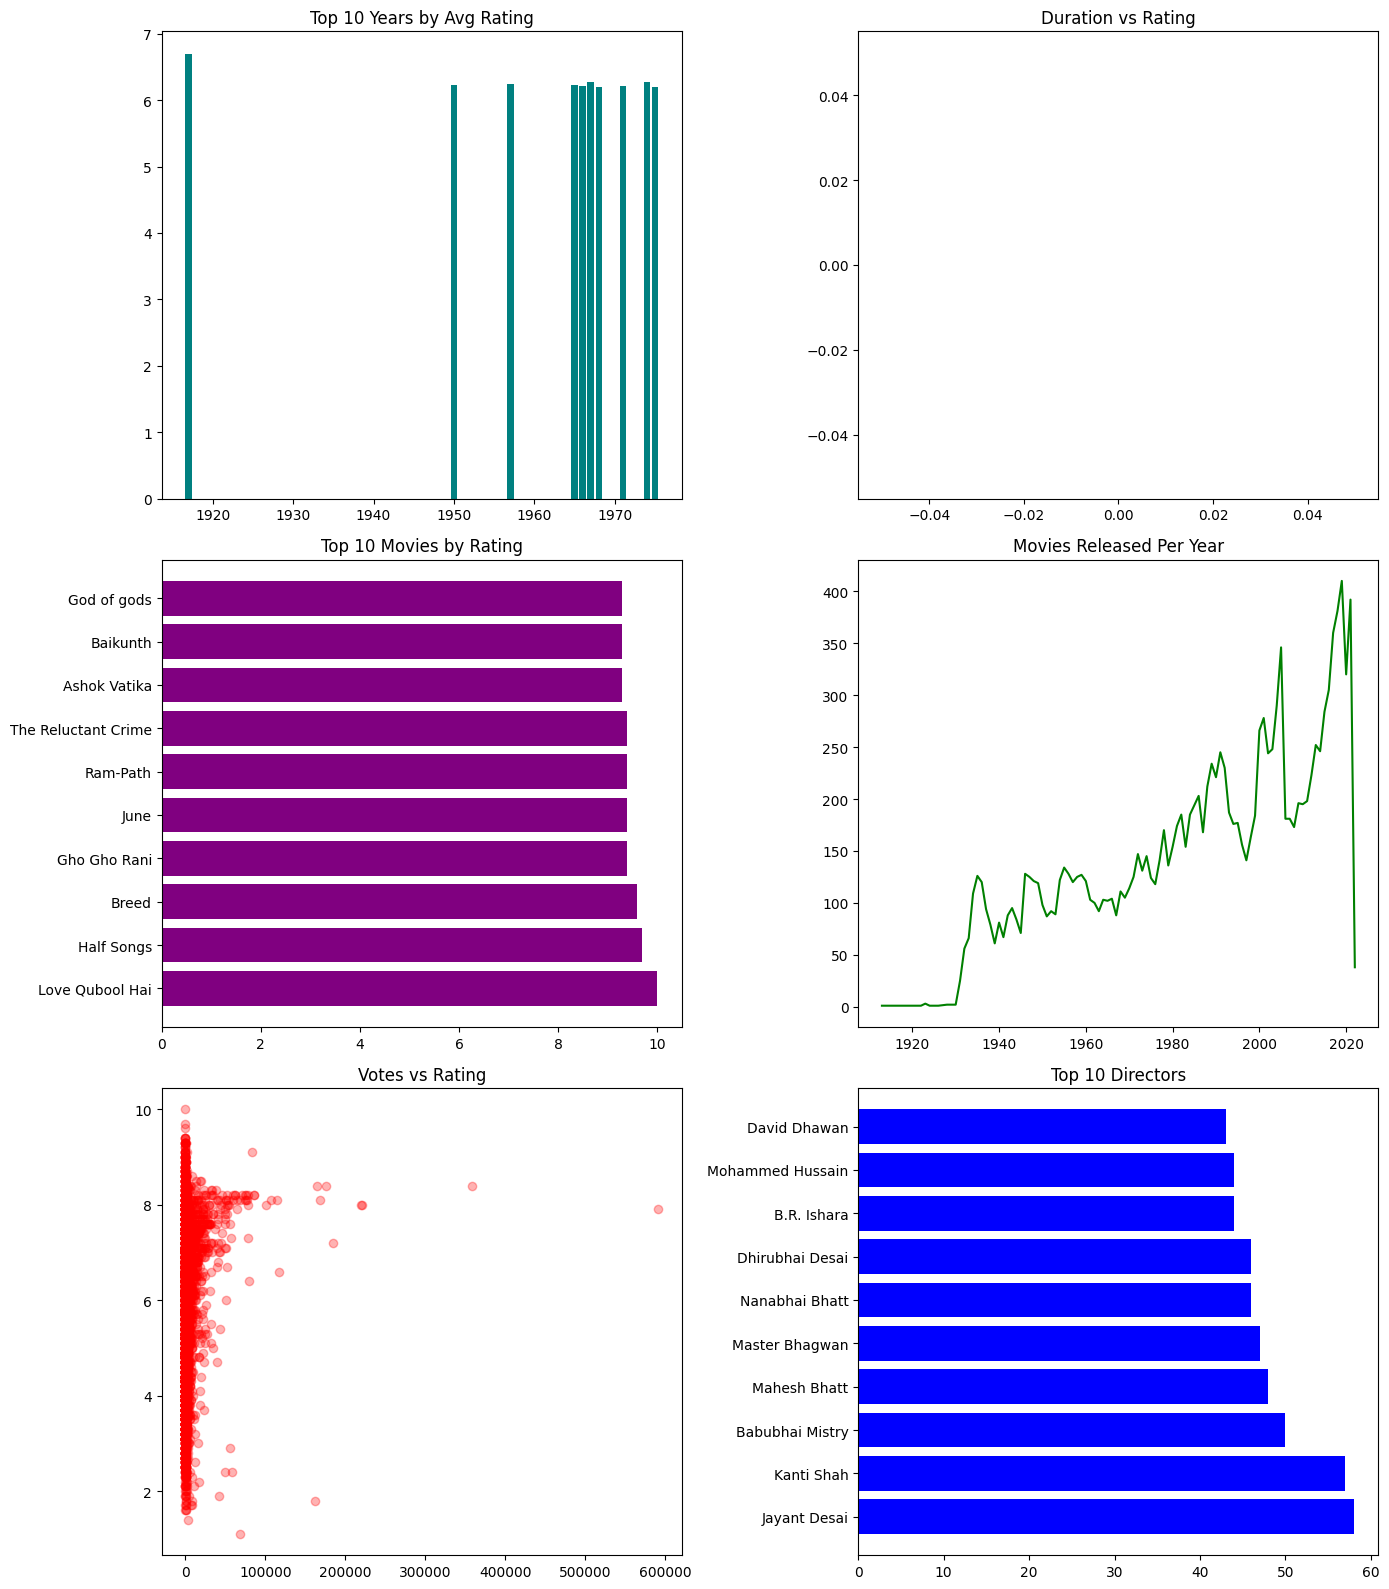

Done!


In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# 1. Year with best avg rating
year_rating = df.groupby('Year')['Rating'].mean().sort_values(ascending=False)
axes[0,0].bar(year_rating.head(10).index.astype(int), year_rating.head(10).values, color='teal')
axes[0,0].set_title('Top 10 Years by Avg Rating')

# 2. Duration vs Rating
axes[0,1].scatter(df['Duration'], df['Rating'], alpha=0.4, color='orange')
axes[0,1].set_title('Duration vs Rating')

# 3. Top 10 movies by rating
top10 = df.nlargest(10, 'Rating')[['Name','Rating']]
axes[1,0].barh(top10['Name'], top10['Rating'], color='purple')
axes[1,0].set_title('Top 10 Movies by Rating')

# 4. Movies per year
movies_year = df.groupby('Year').size()
axes[1,1].plot(movies_year.index, movies_year.values, color='green')
axes[1,1].set_title('Movies Released Per Year')

# 5. Votes vs Rating
axes[2,0].scatter(df['Votes'], df['Rating'], alpha=0.3, color='red')
axes[2,0].set_title('Votes vs Rating')

# 6. Top Directors
top_dir = df['Director'].value_counts().head(10)
axes[2,1].barh(top_dir.index, top_dir.values, color='blue')
axes[2,1].set_title('Top 10 Directors')

plt.tight_layout()
plt.savefig('imdb_eda.png', dpi=150)
plt.show()
print("Done!")

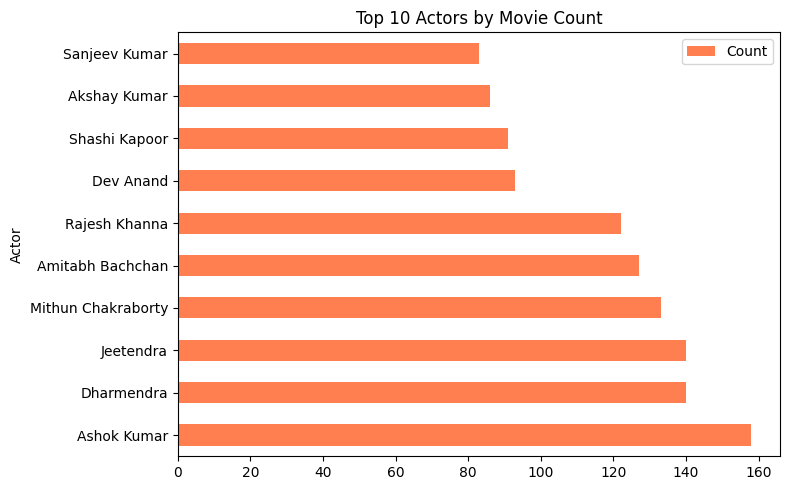

                Actor  Count
0         Ashok Kumar    158
1          Dharmendra    140
2           Jeetendra    140
3  Mithun Chakraborty    133
4    Amitabh Bachchan    127
5       Rajesh Khanna    122
6           Dev Anand     93
7       Shashi Kapoor     91
8        Akshay Kumar     86
9       Sanjeev Kumar     83


In [ ]:

from collections import Counter

all_actors = df['Actor 1'].dropna().tolist()
actor_count = Counter(all_actors)
top_actors = pd.DataFrame(actor_count.most_common(10), columns=['Actor','Count'])

top_actors.plot(kind='barh', x='Actor', y='Count', color='coral', figsize=(8,5))
plt.title('Top 10 Actors by Movie Count')
plt.tight_layout()
plt.savefig('top_actors.png')
plt.show()
print(top_actors)